# CN4 - Cross Spectrum

In [37]:
# import useful libraries
import numpy as np
import matplotlib.pyplot as plt
import torch 

import sys
from pathlib import Path

# set parent directory to sys.path for imports
NOTEBOOK_DIR = Path.cwd().resolve()
PARENT_DIR = NOTEBOOK_DIR.parents[2]
if str(PARENT_DIR) not in sys.path:
    sys.path.insert(0, str(PARENT_DIR))
    print(f"Parent directory added to sys.path: ...\\{PARENT_DIR.name}")
else:
    print(f"Parent directory already in sys.path: ...\\{PARENT_DIR.name}")


# set dataset directory path
DATA_TEST_PATH = PARENT_DIR / "data" / "test"
print("Dataset directory used:", f"...\\{PARENT_DIR.name}\\{DATA_TEST_PATH.relative_to(PARENT_DIR)}")
 
from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch

Parent directory already in sys.path: ...\STL-Dev
Dataset directory used: ...\STL-Dev\data\test


In [38]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


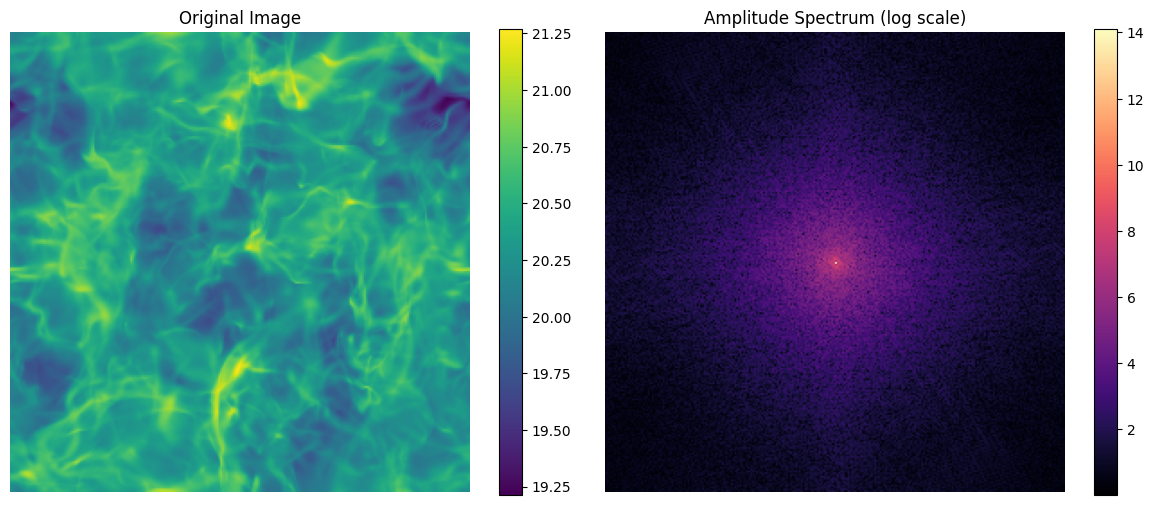

In [39]:
# Load periodic data
im = np.load(str(DATA_TEST_PATH) + "/" + "Turb_6.npy")[0]
im = torch.from_numpy(im).float()

# Compute FFT amplitude spectrum
im_fft = torch.fft.fftshift(torch.fft.fft2(im))
im_fft_amp = torch.abs(im_fft)

# Plot original data and amplitude spectrum
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(im.numpy(), cmap="viridis")
plt.axis("off")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title("Amplitude Spectrum (log scale)")
plt.imshow(torch.log1p(im_fft_amp).numpy(), cmap="magma")
plt.axis("off")
plt.colorbar()

plt.tight_layout()
plt.show()

In [40]:
# Instantiate FFT dataclasse
data = STL_2D_FFT_Torch(array=im, pbc=True)
data_no_pbc = STL_2D_FFT_Torch(array=im, pbc=False)

# Get PS operator   
cs_op = data.get_CS_op(binning_type="legacy")

In [41]:
print("Minimal frequency:", round(cs_op.k_min, 3))
print("Maximal frequency (pre-Nyquist):", round(cs_op.k_max, 3))

Minimal frequency: 0.011
Maximal frequency (pre-Nyquist): 0.354


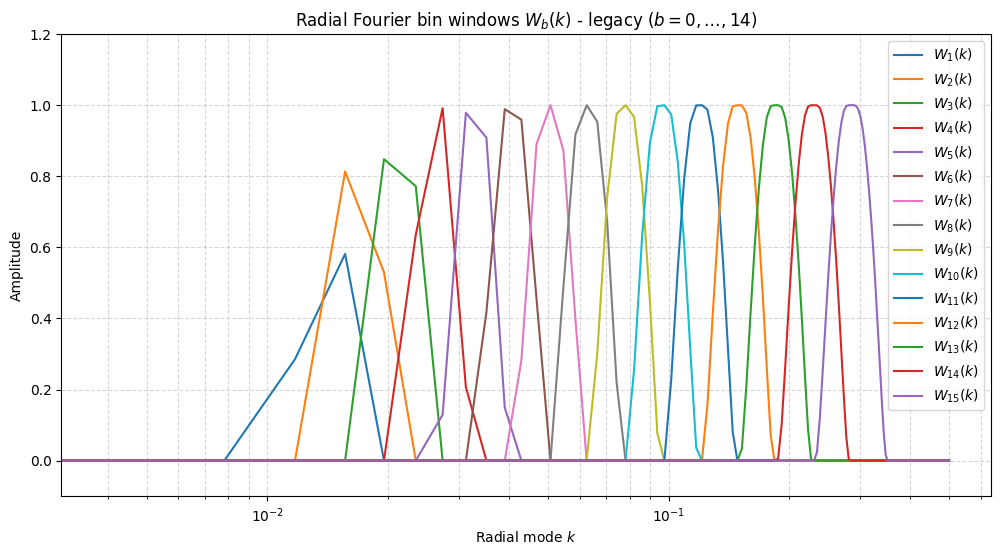

In [42]:
# 1D radial profile of the bin windows + LP check
plt.figure(figsize=(12, 6))
for i in range(cs_op.n_bins):
    plt.plot(cs_op.radial_k, cs_op.bin_windows[i], label=fr"$W_{{{i+1}}}(k)$")

plt.ylim(-0.1, 1.2)
plt.title(
    f"Radial Fourier bin windows $W_b(k)$ - {cs_op.binning_type} "
    f"($b={0},\ldots,{cs_op.n_bins-1}$)"
)
plt.xscale("log")
plt.xlabel("Radial mode $k$")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

In the figure with a linear frequency scale, we observe a degradation in the quality of the wavelets at low frequencies. This can be explained by the image resolution.

Let us check the spectral coverage condition and the bin windows over the range of modes probed by the scattering wavelets.

Note: by construction, the coverage vanishes at the boundary of the last wavelet, at $k_{\max}$.


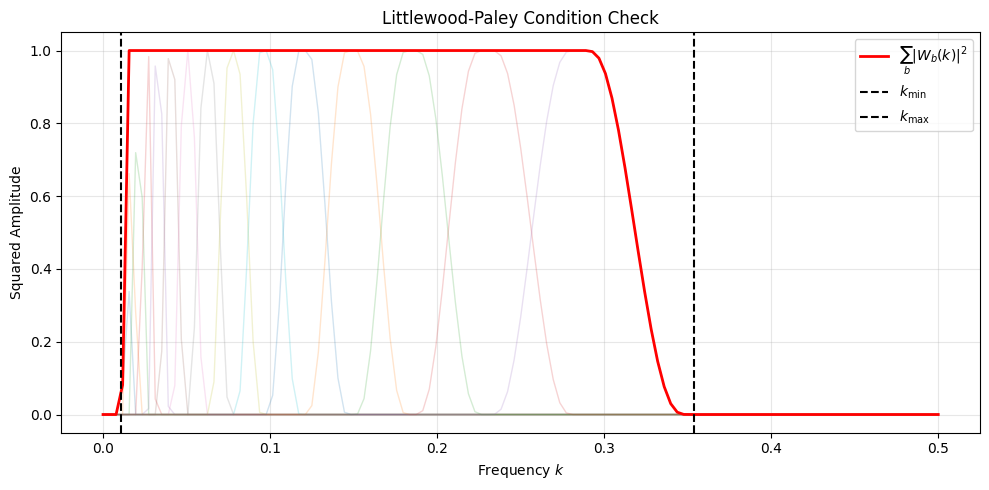

In [43]:
lp_sum = torch.sum(torch.abs(cs_op.bin_windows) ** 2, dim=0)

fig, ax = plt.subplots(figsize=(10, 5))

for i in range(cs_op.n_bins):
    ax.plot(
        cs_op.radial_k,
        cs_op.bin_windows[i] ** 2,
        alpha=0.2,
        lw=1,
    )

ax.plot(
    cs_op.radial_k,
    lp_sum,
    "r",
    lw=2,
    label=r"$\sum_b |W_b(k)|^2$",
)

ax.axvline(
    cs_op.k_min,
    linestyle="--",
    color="k",
    lw=1.5,
    label=r"$k_{\min}$",
)

ax.axvline(
    cs_op.k_max,
    linestyle="--",
    color="k",
    lw=1.5,
    label=r"$k_{\max}$",
)


ax.set_xlabel("Frequency $k$")
ax.set_ylabel("Squared Amplitude")
ax.set_title("Littlewood-Paley Condition Check")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [44]:
print(cs_op.crop_borders)

tensor([47, 40, 45, 39, 34, 26, 21, 18, 14, 12,  9,  8,  6,  5,  5])


Let’s compare the power spectrum of a PBC image using the `fft` and `pbc_mask` methods to check for good agreement between the spectra.


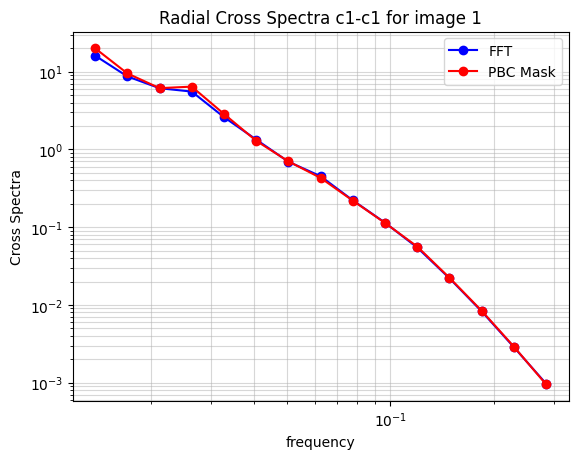

In [49]:
# Compute power spectrum for both periodic and non-periodic data
cross_spectrum= cs_op.apply(data, spectrum_method="fft")
cross_spectrum_pbc_mask = cs_op.apply(data, spectrum_method="pbc_mask")

# Compare power spectra (should be aligned for the same periodic data, even if specified as non periodic)
cs_op.plot_cross_spectrum(cross_spectrum.real, b=0, c1=0, c2=0, label="FFT", color="b")
cs_op.plot_cross_spectrum(cross_spectrum_pbc_mask.real, b=0, c1=0, c2=0, label="PBC Mask", color="r")

Great, it fits pretty well!

The slightly poorer agreement at low frequencies can be explained by the larger number of cropped pixels compared to the smaller scales.

Let's now compare power spectrum between pbc and real non pbc data

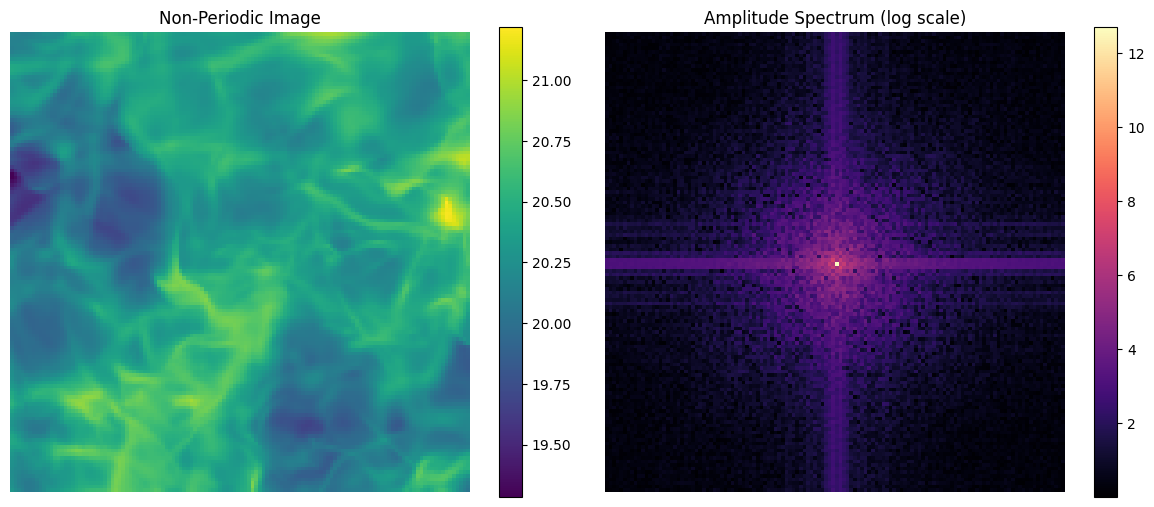

In [50]:
# Extract non periodic portion (128x128) from the original data
im_no_pbc = im[0:128, 0:128]

# Compute FFT amplitude spectrum of non periodic data
im_no_pbc_fft = torch.fft.fftshift(torch.fft.fft2(im_no_pbc))
im_no_pbc_fft_amp = torch.abs(im_no_pbc_fft)

# Plot non periodic data and its amplitude spectrum
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Non-Periodic Image")
plt.imshow(im_no_pbc.numpy(), cmap="viridis")
plt.axis("off")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title("Amplitude Spectrum (log scale)")
plt.imshow(torch.log1p(im_no_pbc_fft_amp).numpy(), cmap="magma")
plt.axis("off")
plt.colorbar()

plt.tight_layout()
plt.show()

The spectral leakage cross is strong here because we crop the original image at the level of a structure, which makes the extracted image highly non-periodic.

In [61]:
# Instantiate FFT dataclasses for both periodic and non-periodic data
data = STL_2D_FFT_Torch(array=im, pbc=True)
data_cropped_no_pbc = STL_2D_FFT_Torch(array=im_no_pbc, pbc=False)

# Get PS operator (different because build on different data shapes)
cs_op = data.get_CS_op()
cs_op_no_pbc = data_cropped_no_pbc.get_CS_op()

# Compute power spectrum for both periodic and non-periodic data
cross_spectrum = cs_op.apply(data).real[0, 0, 0, :]
cross_spectrum_no_pbc_fft = cs_op_no_pbc.apply(data_cropped_no_pbc, spectrum_method="fft").real[0, 0, 0, :]
cross_spectrum_no_pbc_pbc_mask = cs_op_no_pbc.apply(data_cropped_no_pbc, spectrum_method="pbc_mask").real[0, 0, 0, :]

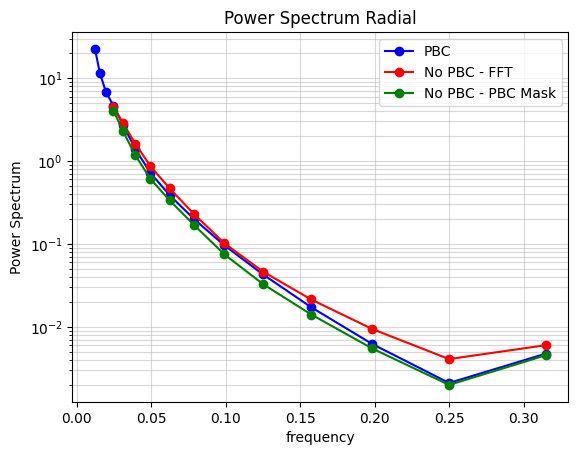

In [63]:
# Plot power spectra for both periodic and non-periodic data
plt.plot(cs_op.bin_centers, cross_spectrum, "-", marker="o", label="PBC", color="b")
plt.plot(cs_op_no_pbc.bin_centers, cross_spectrum_no_pbc_fft, "-", marker="o", label="No PBC - FFT", color="r")
plt.plot(cs_op_no_pbc.bin_centers, cross_spectrum_no_pbc_pbc_mask, "-", marker="o", label="No PBC - PBC Mask", color="g")

plt.yscale("log")
plt.xlabel("frequency")
plt.ylabel("Power Spectrum")
plt.title("Power Spectrum Radial")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()

The two power spectra are not defined over the same frequency range, i.e at the largest spatial scales, because the two images have different sizes (the PBC image is 256×256, while the non-PBC image is 128×128). The agreement is better with `pbc_mask` over the spatial scales that can be probed by both maps.


Let's compare the cross-power spectra of a PBC image using both the `fft` and `pbc_mask` methods.

In [66]:
im = np.load(str(DATA_TEST_PATH) + "/" + "Turb_6.npy")[:3] # Take 3 channels for cross spectrum

# Instantiate FFT dataclasse
data = STL_2D_FFT_Torch(array=im, pbc=True)
data_no_pbc = STL_2D_FFT_Torch(array=im, pbc=False)

# Get PS operator
cs_op = data.get_CS_op()

# Compute power spectrum for both periodic and non-periodic data
compute_cross_spectrum_matrix = torch.tensor([[True, True, True],[False, True, True],[False, False, True]])
cross_spectrum = cs_op.apply(data, compute_cross_spectrum_matrix=compute_cross_spectrum_matrix)
cross_spectrum_no_pbc = cs_op.apply(data_no_pbc, compute_cross_spectrum_matrix=compute_cross_spectrum_matrix)

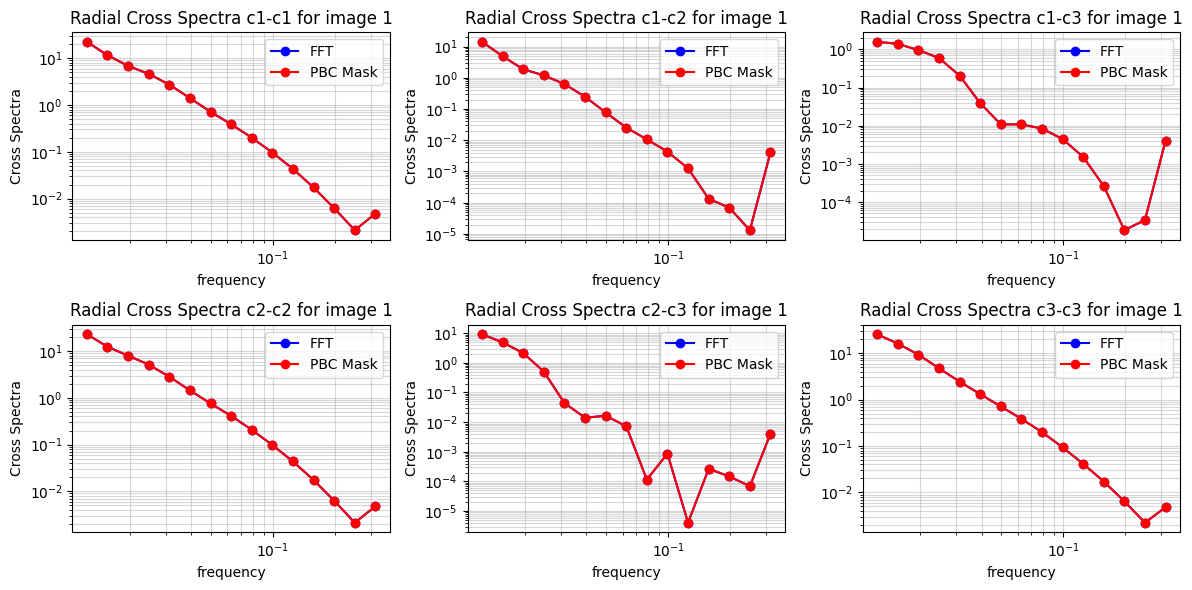

In [69]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.ravel()

pairs = [(0,0), (0,1), (0,2), (1,1), (1,2), (2,2)]

for i, (c1, c2) in enumerate(pairs):
    plt.sca(axes[i])

    cs_op.plot_cross_spectrum(
        cross_spectrum.abs(), b=0, c1=c1, c2=c2,
        label="FFT", color="b"
    )

    cs_op.plot_cross_spectrum(
        cross_spectrum_no_pbc.abs(), b=0, c1=c1, c2=c2,
        label="PBC Mask", color="r"
    )
    
    plt.legend()

plt.tight_layout()
plt.show()